In [1]:
import pandas as pd

# Load the dataframe from CSV
df = pd.read_csv(r"..\..\data\cleaned_data_w_class.csv")


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\adm1\AppData

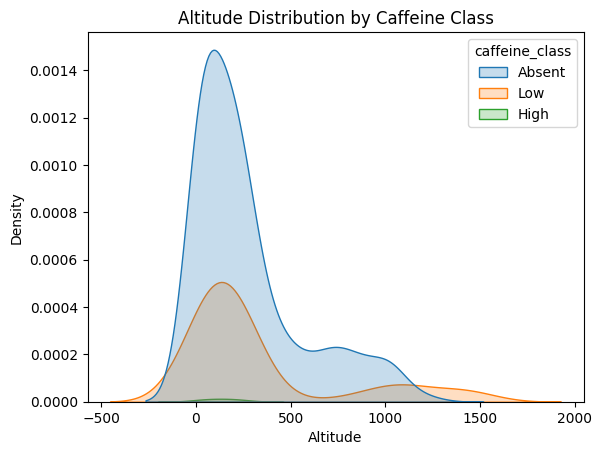

In [2]:
# Grouping by caffeine class and calculating summary statistics
altitude_summary = df.groupby('caffeine_class')['env_71_alt'].describe()

# Visualizing distributions
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df, x='env_71_alt', hue='caffeine_class', fill=True)
plt.title('Altitude Distribution by Caffeine Class')
plt.xlabel('Altitude')
plt.ylabel('Density')
plt.show()

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


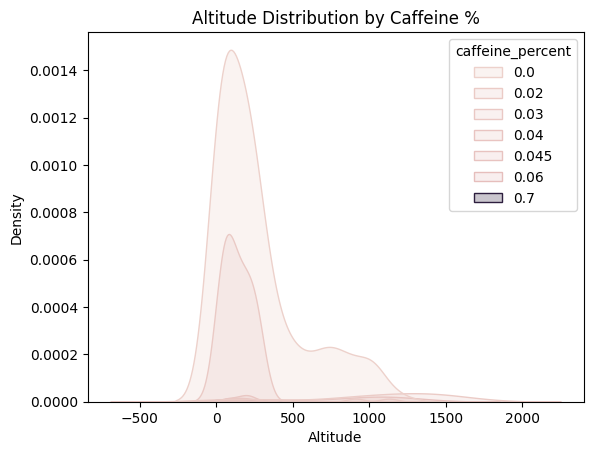

In [3]:
# Grouping by caffeine class and calculating summary statistics
altitude_summary = df.groupby('caffeine_percent')['env_71_alt'].describe()

# Visualizing distributions
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df, x='env_71_alt', hue='caffeine_percent', fill=True)
plt.title('Altitude Distribution by Caffeine %')
plt.xlabel('Altitude')
plt.ylabel('Density')
plt.show()

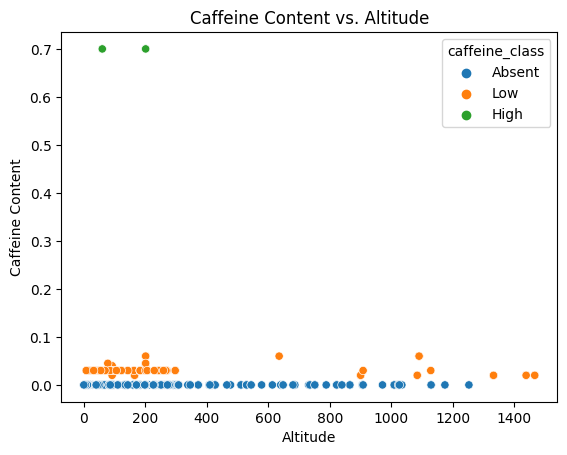

                  env_71_alt  caffeine_percent
env_71_alt          1.000000         -0.003677
caffeine_percent   -0.003677          1.000000


In [5]:
# Scatterplot
sns.scatterplot(data=df, x='env_71_alt', y='caffeine_percent', hue='caffeine_class')
plt.title('Caffeine Content vs. Altitude')
plt.xlabel('Altitude')
plt.ylabel('Caffeine Content')
plt.show()

# Correlation
correlation = df[['env_71_alt', 'caffeine_percent']].corr()
print(correlation)

caffeine_class    Absent      High       Low
altitude_range                              
0-500m          0.716312  0.004728  0.278960
500-1000m       0.900000  0.000000  0.100000
1000-1500m      0.461538  0.000000  0.538462
1500-2000m      0.000000  0.000000  0.000000
>2000m          0.000000  0.000000  0.000000


C:\Users\adm1\AppData\Local\Temp\ipykernel_90452\1999569955.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  altitude_class_distribution = df.groupby('altitude_range')['caffeine_class'].value_counts(normalize=True).unstack()


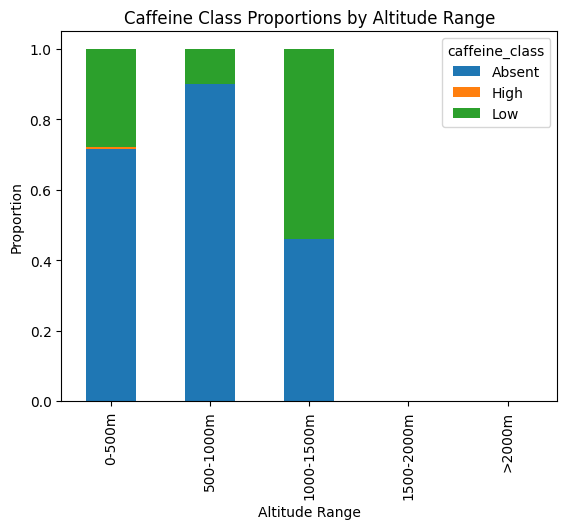

In [6]:
# Binning altitudes
df['altitude_range'] = pd.cut(df['env_71_alt'], bins=[0, 500, 1000, 1500, 2000, float('inf')], 
                              labels=['0-500m', '500-1000m', '1000-1500m', '1500-2000m', '>2000m'])

# Calculating proportions
altitude_class_distribution = df.groupby('altitude_range')['caffeine_class'].value_counts(normalize=True).unstack()

print(altitude_class_distribution)

# Barplot
altitude_class_distribution.plot(kind='bar', stacked=True)
plt.title('Caffeine Class Proportions by Altitude Range')
plt.xlabel('Altitude Range')
plt.ylabel('Proportion')
plt.show()


In [7]:
from scipy.stats import ttest_ind, mannwhitneyu

# T-test
caffeinated = df[df['caffeine_class'] == 'Caffeinated']['env_71_alt']
non_caffeinated = df[df['caffeine_class'] == 'Non-Caffeinated']['env_71_alt']

t_stat, p_val = ttest_ind(caffeinated, non_caffeinated)
print(f"T-test: t-stat={t_stat}, p-value={p_val}")


T-test: t-stat=nan, p-value=nan


C:\Users\adm1\AppData\Local\Temp\ipykernel_90452\3757482624.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = ttest_ind(caffeinated, non_caffeinated)


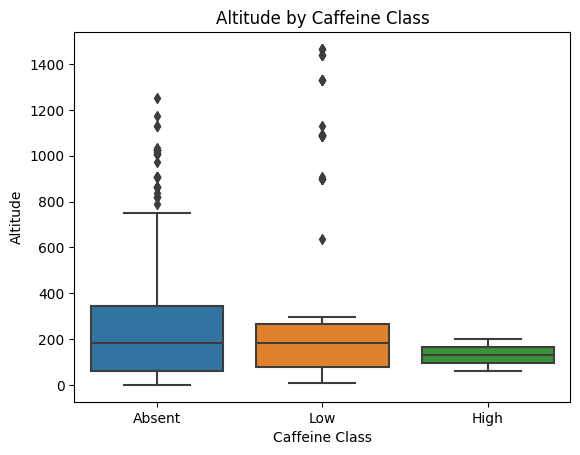

In [8]:
# Boxplot
sns.boxplot(data=df, x='caffeine_class', y='env_71_alt')
plt.title('Altitude by Caffeine Class')
plt.xlabel('Caffeine Class')
plt.ylabel('Altitude')
plt.show()


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\adm1\AppData

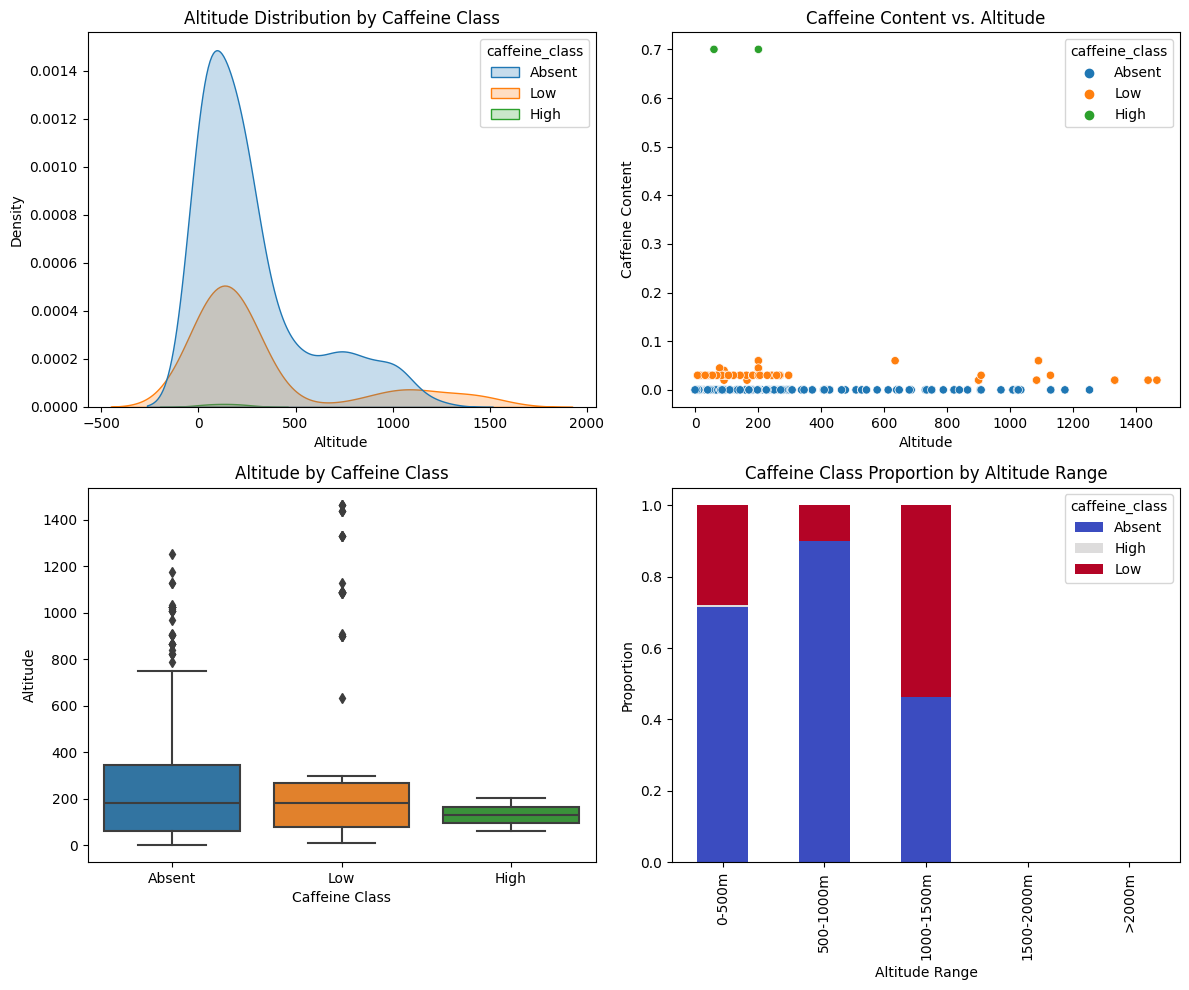

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Density Plot
sns.kdeplot(data=df, x='env_71_alt', hue='caffeine_class', fill=True, ax=axes[0, 0])
axes[0, 0].set_title('Altitude Distribution by Caffeine Class')
axes[0, 0].set_xlabel('Altitude')
axes[0, 0].set_ylabel('Density')

# 2. Scatterplot
sns.scatterplot(data=df, x='env_71_alt', y='caffeine_percent', hue='caffeine_class', ax=axes[0, 1])
axes[0, 1].set_title('Caffeine Content vs. Altitude')
axes[0, 1].set_xlabel('Altitude')
axes[0, 1].set_ylabel('Caffeine Content')

# 3. Boxplot
sns.boxplot(data=df, x='caffeine_class', y='env_71_alt', ax=axes[1, 0])
axes[1, 0].set_title('Altitude by Caffeine Class')
axes[1, 0].set_xlabel('Caffeine Class')
axes[1, 0].set_ylabel('Altitude')

# 4. Caffeine Class Proportion by Altitude Range
df['altitude_range'] = pd.cut(df['env_71_alt'], bins=[0, 500, 1000, 1500, 2000, float('inf')],
                              labels=['0-500m', '500-1000m', '1000-1500m', '1500-2000m', '>2000m'])
altitude_class_distribution = df.groupby('altitude_range')['caffeine_class'].value_counts(normalize=True).unstack()

altitude_class_distribution.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='coolwarm')
axes[1, 1].set_title('Caffeine Class Proportion by Altitude Range')
axes[1, 1].set_xlabel('Altitude Range')
axes[1, 1].set_ylabel('Proportion')

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
